In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from brokenaxes import brokenaxes
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.markers import MarkerStyle

def fps_huansuan(Data,fps_col,gpu_col,gpu='a100'):
    hs=[
        ['1070','1080','1080ti','titanx','titanxp',
         '2080ti','p6000','titanv','titan','v100','3080ti','3090',
         '3090ti','a100','no','a6000','3080'],
        [5.3, 6.7, 8, 9, 9,
         14, 14, 15, 16, 18, 19, 22,
         23,25,18,22,18]
    ]
    new_beilv=-1
    for i in range(len(hs[0])):
        if gpu==hs[0][i]:
            new_beilv=hs[1][i]
            break
    for i in range(len(Data)):
        old_beilv=-1
        for j in range(len(hs[0])):
            if Data[i][gpu_col]==hs[0][j]:
                
                old_beilv=hs[1][j]
#                 print(Data[i][gpu_col],hs[0][j],old_beilv,new_beilv)
                break
        Data[i][fps_col]=round(Data[i][fps_col]/old_beilv*new_beilv,0)
    return Data

def get_markers():
    # 自定义路径0：向上标
    custom_marker0_path = Path([(-0.5, 0), (0, 1), (0.5, 0), (0.5, -1), (0, 0), (-0.5, -1), (-0.5, 0)])
    custom_marker0 = MarkerStyle(marker=custom_marker0_path)
    # 自定义路径1：向下标
    custom_marker1_path = Path([(-0.5, 1), (0, 0), (0.5, 1), (0.5, 0),(0, -1),(-0.5, 0), (-0.5, 1)])
    custom_marker1 = MarkerStyle(marker=custom_marker1_path)
    # 自定义路径2：向左标
    custom_marker2_path = Path([(1, 0.5), (0, 0), (1, -0.5),(0, -0.5), (-1, 0),(0, 0.5),(1, 0.5)])
    custom_marker2 = MarkerStyle(marker=custom_marker2_path)
    # 自定义路径3：向右标
    custom_marker3_path = Path([(0, 0.5), (1, 0), (0, -0.5), (-1, -0.5), (0, 0),(-1, 0.5),(0, 0.5)])
    custom_marker3 = MarkerStyle(marker=custom_marker3_path)
    markers = ['o', 's', '^', 'v', '<', '>', 'p', 'H', '*', 
                custom_marker0,custom_marker1,custom_marker2,custom_marker3,'D',]
    return markers

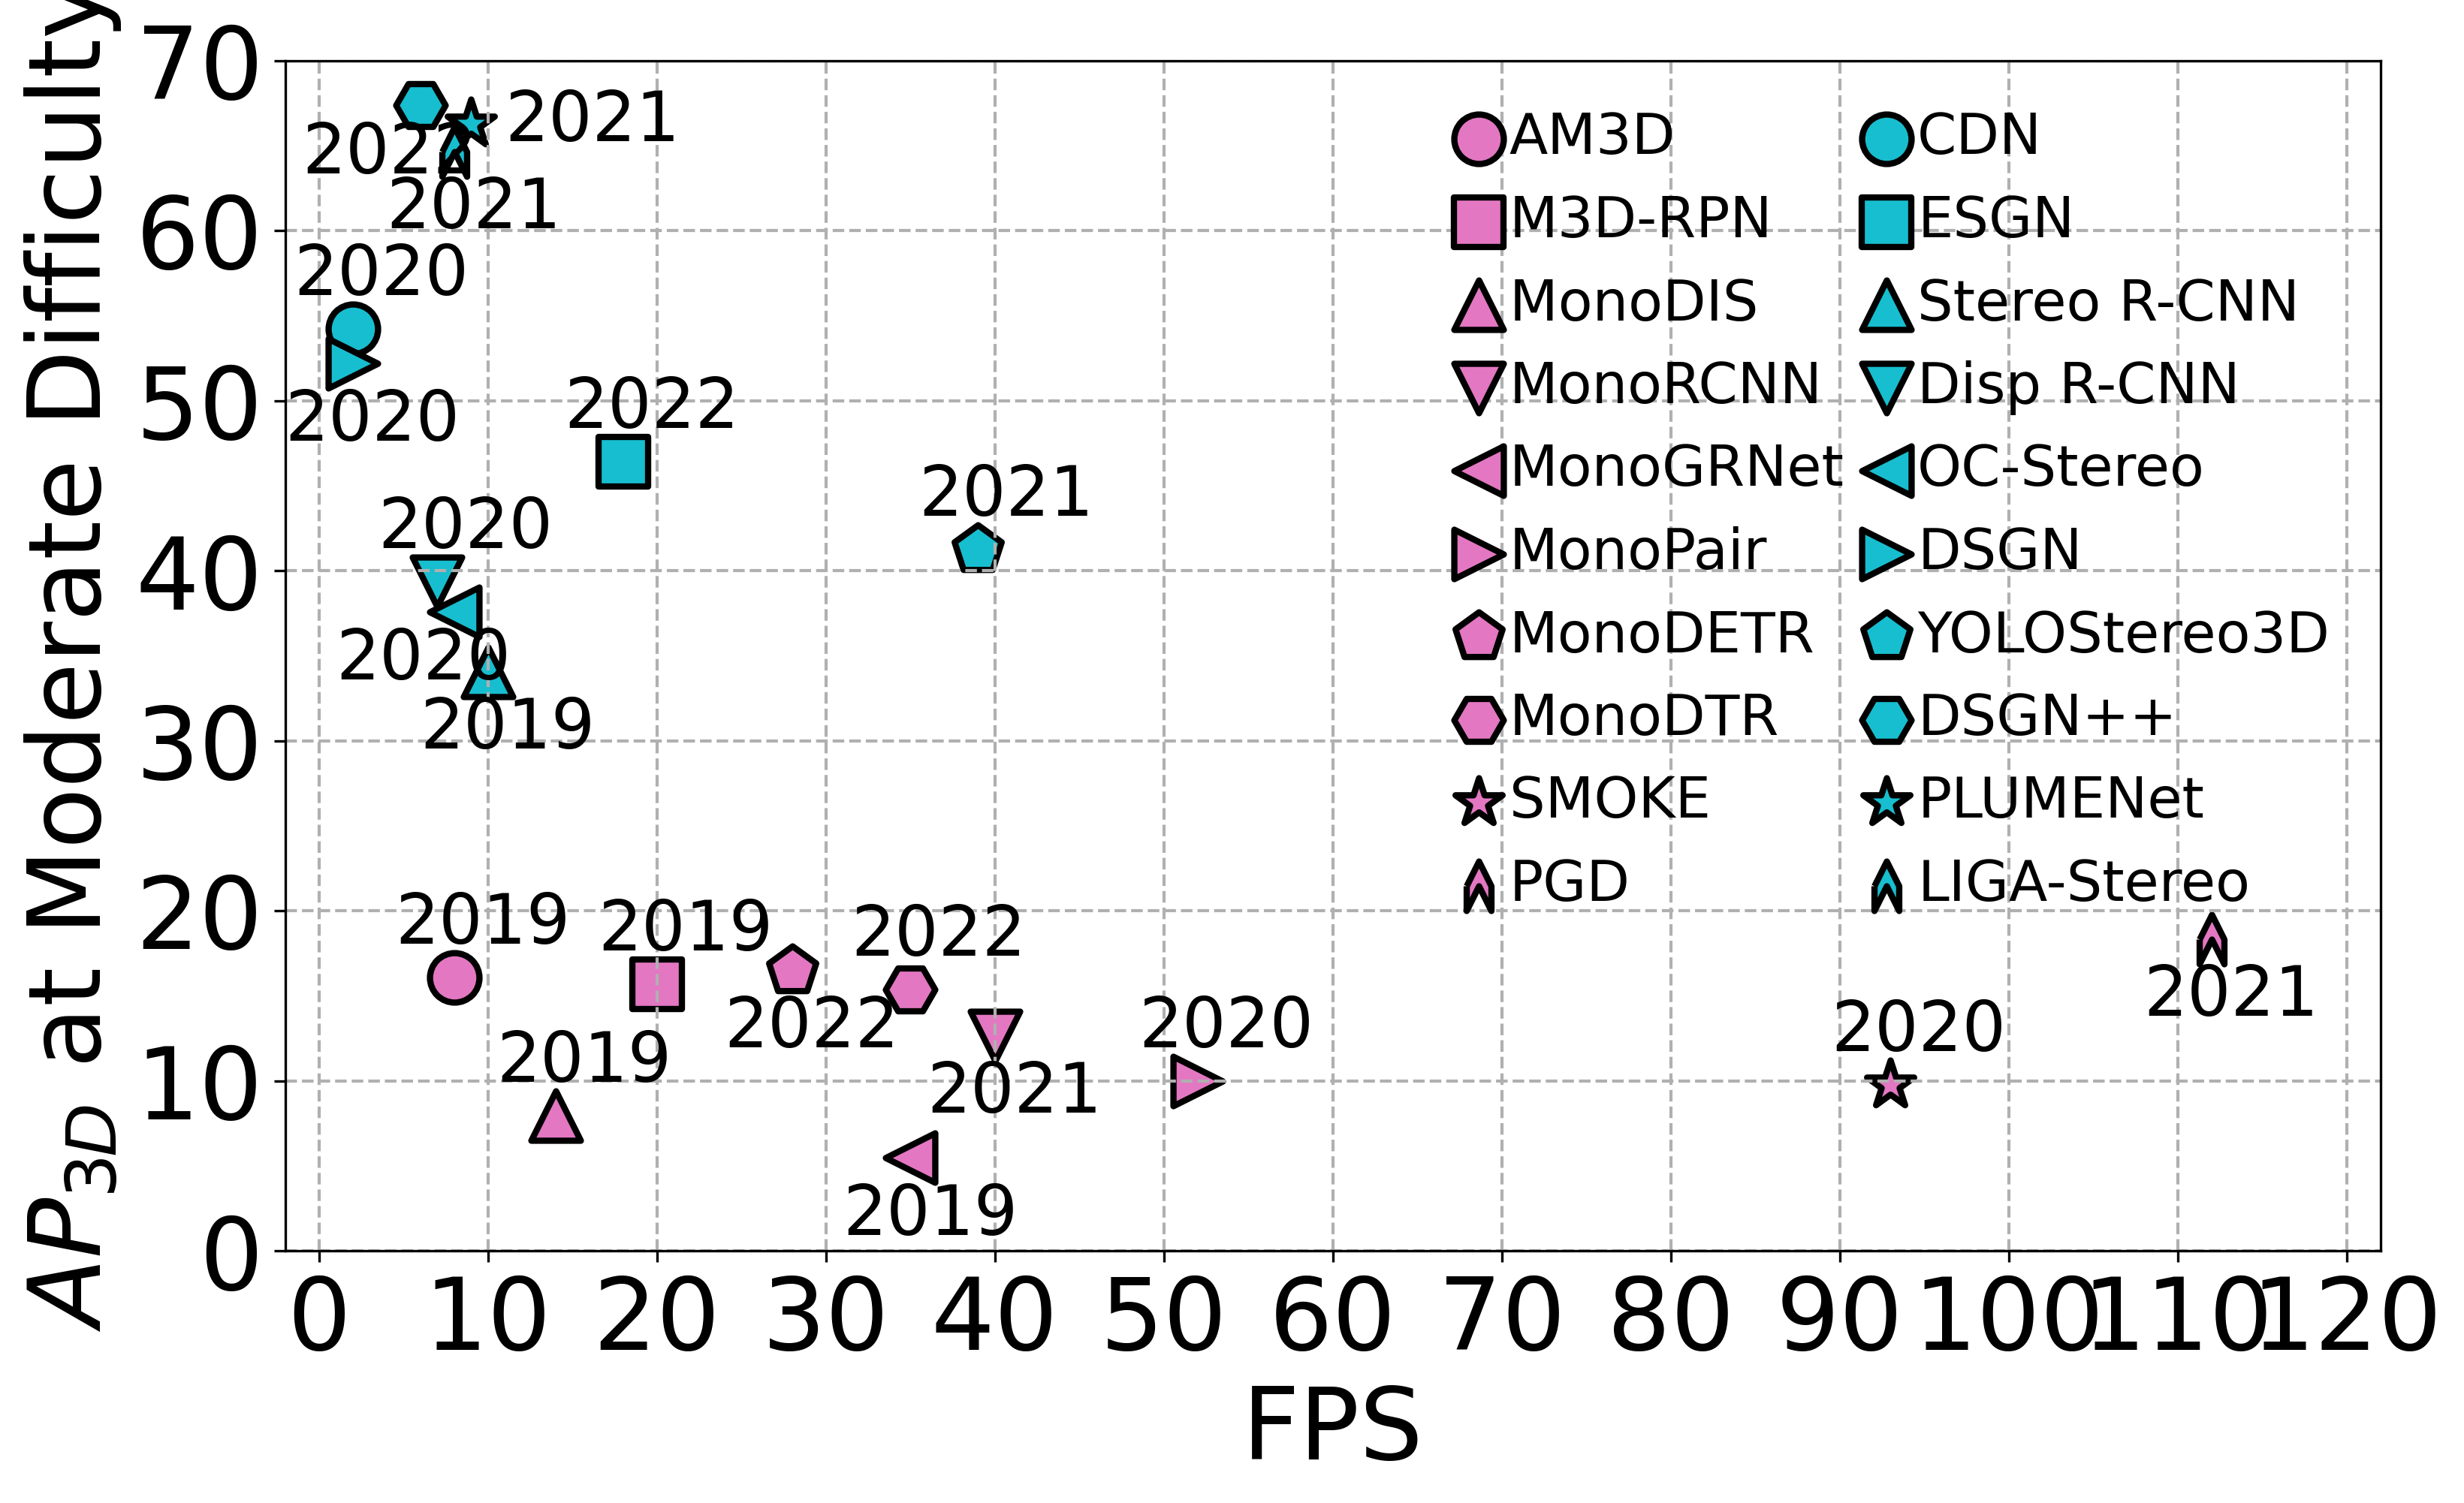

In [2]:
DATA1=[
    # dan
    ['AM3D',1000/400,21.48,16.08,15.26,'2019','1080ti','d'],#原文21.48,16.08,15.26,1080ti,1000/400/14*43=
    ['M3D-RPN',1000/160,20.65,15.70,13.32,'2019','1080ti','d'],#原文20.65,15.70,13.32,1080ti,1000/160/14*43=
    ['MonoDIS ',1000/100,10.37, 7.94, 6.40,'2019','v100','d'],#原文10.37,7.94,6.40,v100,1000/100/19*43=
    ['MonoRCNN',1000/70,18.36, 12.65, 10.03,'2021','titanx','d'],#原文18.36,12.65,10.03,TITAN X,1000/70/15*43=
    ['MonoGRNet',1000/40,9.61,5.47,4.25,'2019','no','d'],#原文只给了val，无test（榜单有），无显卡
    ['MonoPair',1000/60,13.04,9.99,8.65,'2020','1080ti','d'],#原文13.04,9.99,8.65,1080ti,1000/60/14*43=
    ['MonoDETR',1000/40,25.00,16.47,13.58,'2022','3090','d'],#原文25.00,16.47,13.58,3090,1000/40
    ['MonoDTR',1000/40,21.99,15.39,12.73,'2022','v100','d'],#原文21.99,15.39,12.73,v100,1000/40/19*43=
    ['SMOKE',1000/30,14.03,9.76,7.84,'2020','titanx','d'],#原文14.03,9.76,7.84,TITAN X,1000/30/15*43=
    ['PGD',1000/28,24.35,18.34,16.90 ,'2021','1080ti','d'],#原文24.35,18.34,16.90,1080ti,1000/28/14*43=
    # shuang
    ['CDN',1000/600,74.52,54.22,46.36,'2020','no','s'],#原文74.52,54.22,46.36,无显卡,
    ['ESGN',1000/62,65.80,46.39,38.42,'2022','3090','s'],#原文65.80,46.39,38.42,3090+0.062s,1000/62=
    ['Stereo R-CNN',1000/280,49.23,34.05,28.39,'2019','titanxp','s'],#原文49.23,34.05,28.39,TITAN XP+0.28s,1000/280/15*43=
    ['Disp R-CNN',1000/425,59.58,39.34,31.99,'2020','titanxp','s'],#原文59.58,39.34,31.99,12G卡+0.425s,1000/420/15*43=
    ['OC-Stereo',1000/350,55.15,37.60,30.25,'2020','titanxp','s'],#原文55.11,38.80,31.86,TITAN XP+0.35s,1000/350/15*43=
    ['DSGN',1000/682,73.50,52.18,45.14,'2020','v100','s'],#原文73.50,52.18,45.14,v100+0.682s,1000/670/19*43=
    ['YOLOStereo3D',1000/80,65.68,41.25,30.42,'2021','1080ti','s'],#原文65.68,41.25,30.42,1080ti,由zoomnet改变
    ['DSGN++',1000/281,83.21,67.37,59.91,'2022','2080ti','s'],#原文没单独给car的ap，2080ti+0.281s,1000/281/16*43=
    ['PLUMENet',1000/150,82.97 ,66.27 ,56.70,'2021','v100','s'],#原文83.3,66.3,56.7,v100+0.150ms,1000/150/19*43=
    ['LIGA-Stereo',1000/350,81.39, 64.66, 57.22, '2021','titanxp','s'],#原文81.39 64.66 57.22,TITAN XP+0.35s,1000/350/15*43=
]

def draw1(Data):
    # 换算fps
    Data=fps_huansuan(Data,1,6,'a100')
    # 从Data中按照列取数据
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]  # Calculating FPS from delays
    aps_moderate = [item[3] for item in Data]
    researcher_types = [item[7] for item in Data]
    years = [item[5] for item in Data]
    # 画布大小、dpi
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
    # 画散点的循环
    for i, researcher_type in enumerate(researcher_types):
        # 每个网络种类内点的形状按照get_markers给出的序列进行循环
        markers = get_markers()
        # 按照网络种类进行点的颜色的循环
        colors = [f'C{6}',f'C{9}']  
        if researcher_type=='d':
            c = colors[0] 
        else:
            c = colors[1]
        # 点的尺寸
        size = 250  
        # 画散点
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%10], label=model_names[i], 
                   color=c, s=size,edgecolor='black',linewidth=2)
        # 在散点周围标注年份
        offset = 1
        text_size=22
        if i==3 or i==4 or i==6 or i==9 or i==15 or i==19 or i==12:#正下方
            ax.text(delays[i]-4*offset, aps_moderate[i]- 4.5*offset, years[i], fontsize=text_size, color='black')
        elif  i==14 or i==17:#左下方
            ax.text(delays[i]-7*offset, aps_moderate[i]- 4*offset, years[i], fontsize=text_size, color='black')
        elif i==18:#正右侧
            ax.text(delays[i]+2*offset, aps_moderate[i]- 1*offset, years[i], fontsize=text_size, color='black')
        else:#正上方
            ax.text(delays[i]-3.5*offset, aps_moderate[i] + 2*offset, years[i], fontsize=text_size, color='black')
    # 画布上的其他设置：x轴、y轴、图例、网格线等
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel(r'$AP_{3D}$'+' at Moderate Difficulty',fontsize=32)
    ax.set_xticks(np.arange(0, 120.00001, 10))
    ax.set_yticks(np.arange(0, 70.1, 10))
    ax.set_xlim(-2, 122)
    ax.set_ylim(0, 70)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=2,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5,columnspacing=1)  # 2 columns in legend
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"
    # 存储图像
    plt.savefig('./mono+stereo_kitti_moderate_ap+fps.png',bbox_inches='tight')
    plt.show()

draw1(DATA1)

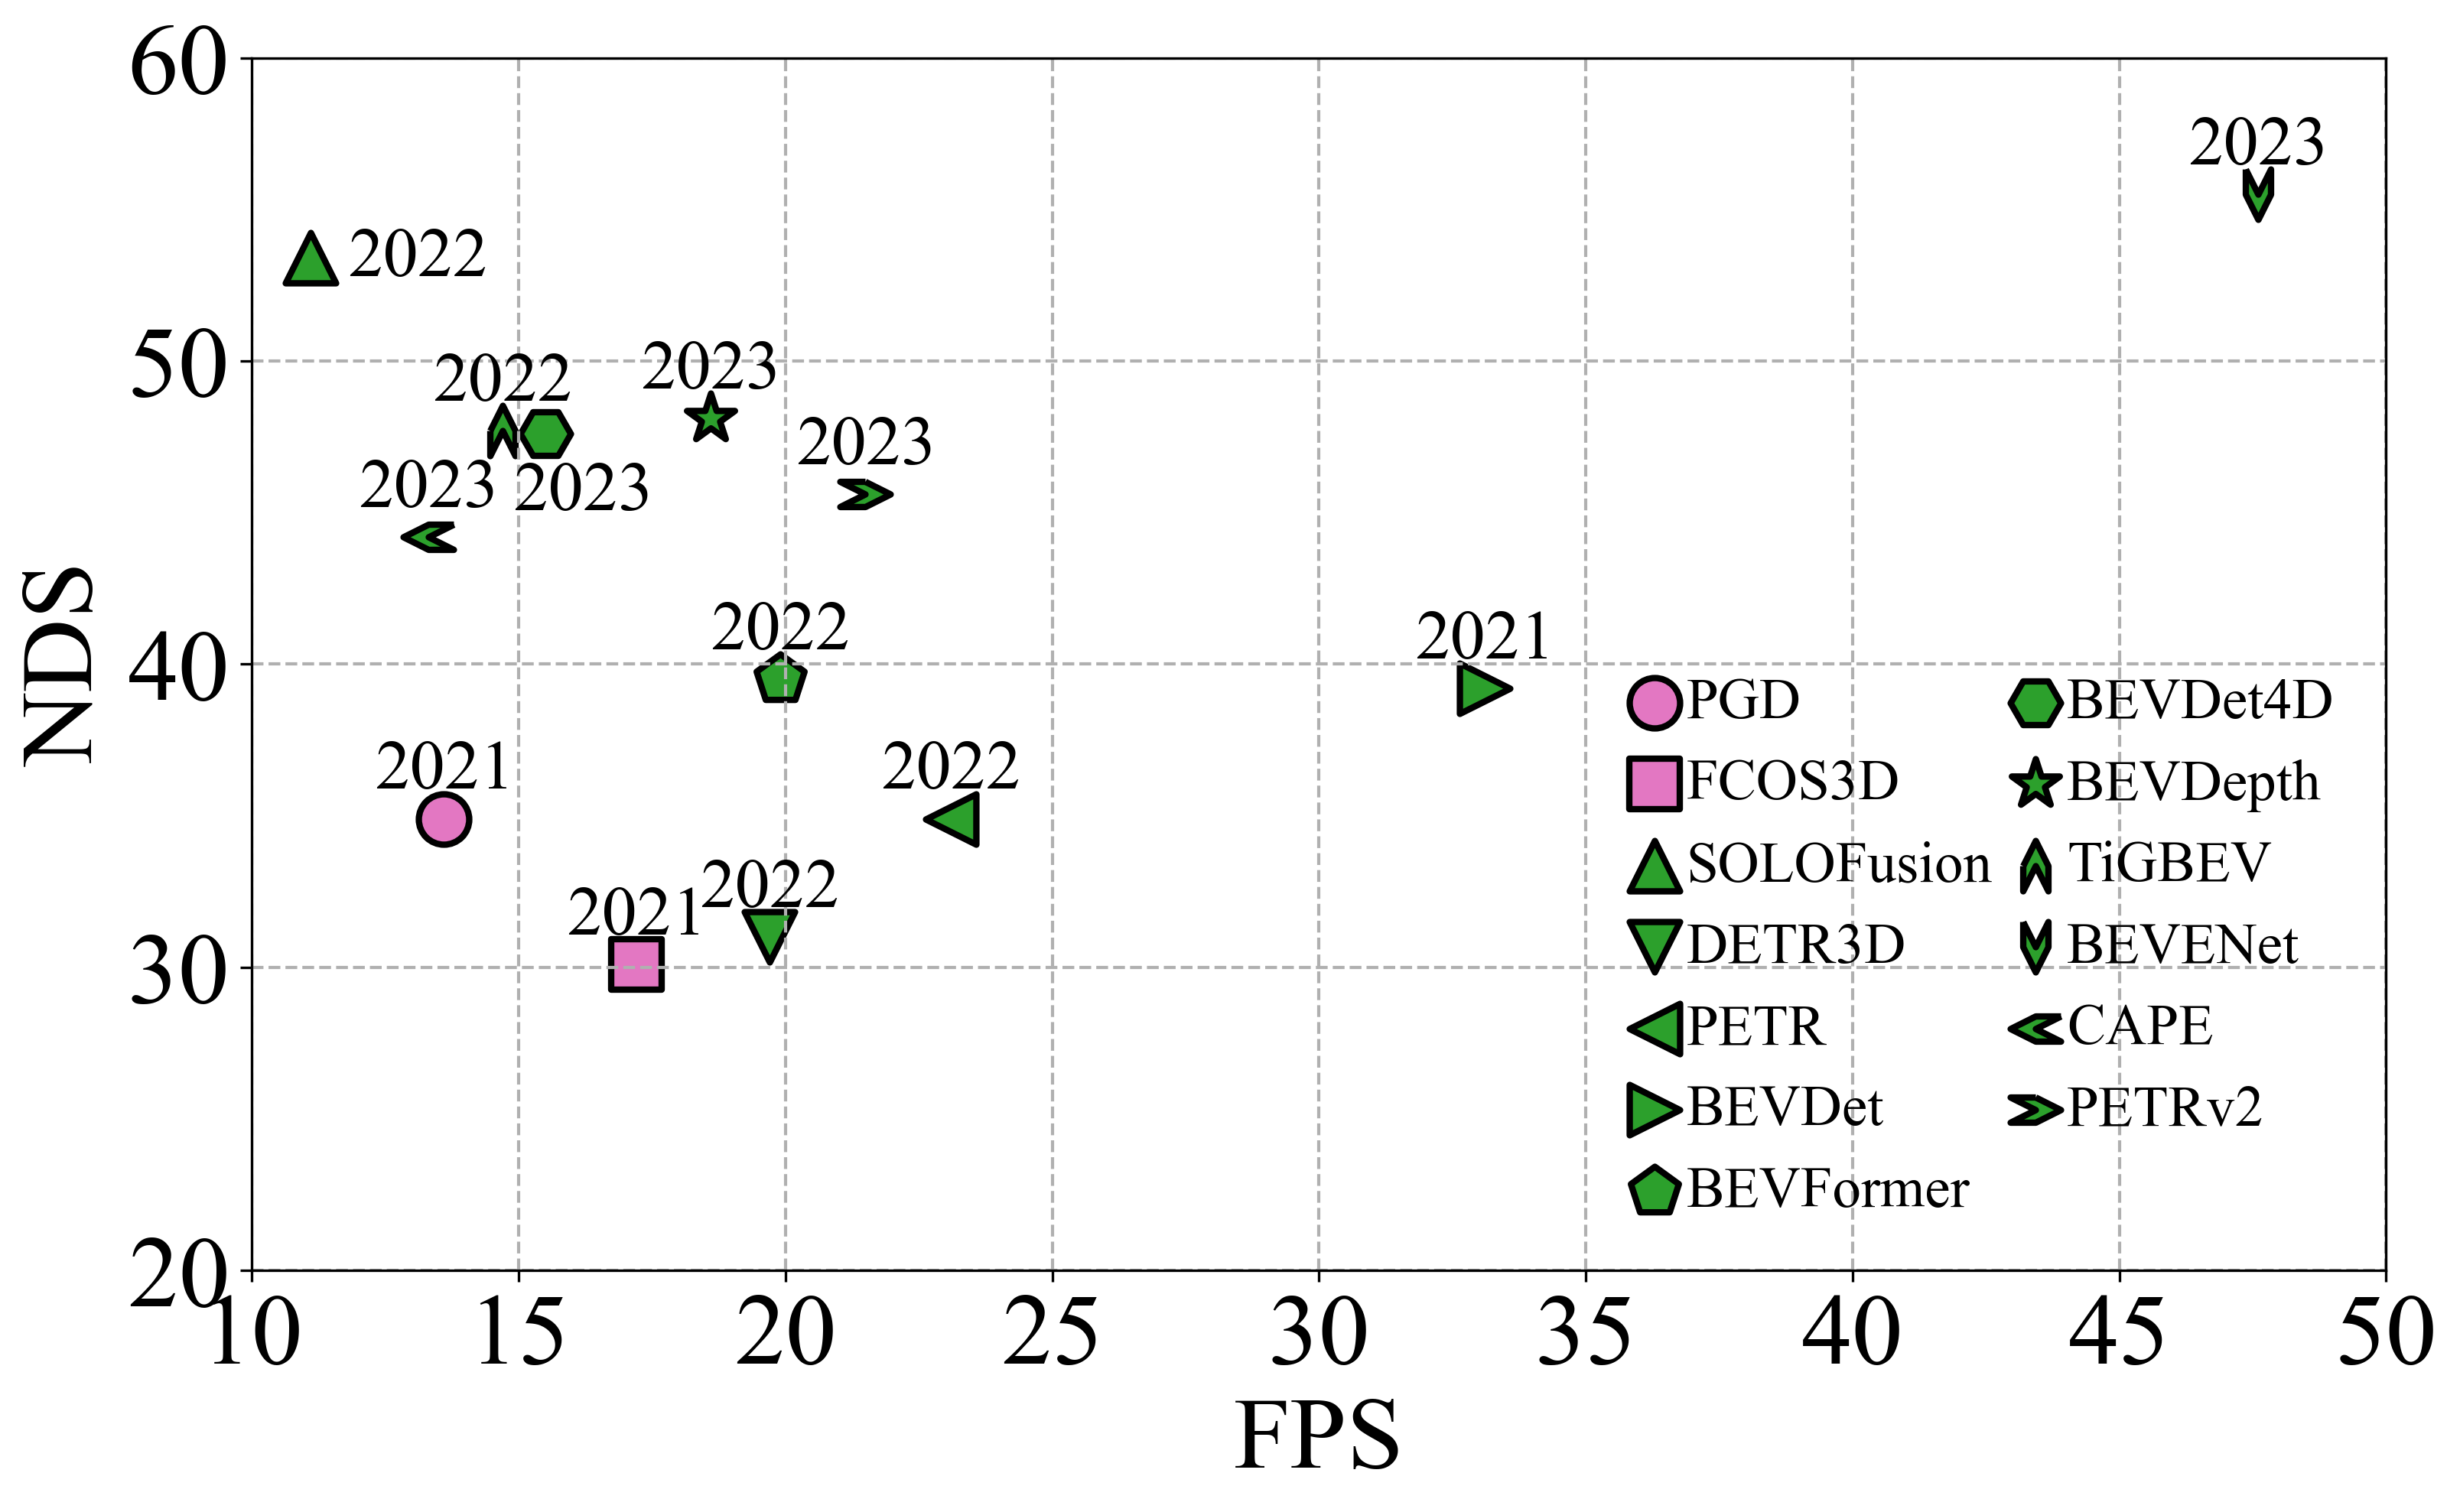

In [3]:
DATA2=[
    # dan
    ['PGD',13.6,34.9,'2021','d'],
    ['FCOS3D',17.2,30.1 ,'2021','d'],
    # duoshitu
    ['SOLOFusion',11.1,53.4,'2022','m'],
    ['DETR3D',19.7,31.0,'2022','m'],
    ['PETR',23.1,34.9,'2022','m'],
    ['BEVDet',33.1,39.2,'2021','m'],
    ['BEVFormer',19.9,39.5,'2022','m'],
    ['BEVDet4D',15.5,47.6,'2023','m'],
    ['BEVDepth',18.6,48.1,'2023','m'],
    ['TiGBEV',14.7,47.7,'2022','m'],
    ['BEVENet',47.6,55.5,'2023','m'],
    ['CAPE',13.3,44.2,'2023','m'],
    ['PETRv2',21.5,45.6,'2023','m'],#3090+18.9
]

def draw2(Data):
    # 换算fps
    ## 这里没有用调用换算函数是因为：数据都来自3090，只有一条不是来自3090的已经手动换算了
    # 从Data中按照列取数据
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]  # Calculating FPS from delays
    aps_moderate = [item[2] for item in Data]
    researcher_types = [item[4] for item in Data]
    years = [item[3] for item in Data]
    # 画布大小、dpi
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
    # 画散点的循环
    for i, researcher_type in enumerate(researcher_types):
        # 按照网络种类进行点的颜色的循环
        ## draw1和draw2同样种类的方法是公用颜色的
        ### 点云、多模态部分的两个图同样按照种类公用颜色
        colors = [f'C{6}',f'C{12}']
        # 每个网络种类内点的形状按照get_markers给出的序列进行循环
        markers = get_markers()
        # 点的尺寸
        size = 250
        # 画散点
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%len(markers)], label=model_names[i], 
                   color=[colors[0] if i<=1 else colors[1]], s=size,edgecolor='black',linewidth=2)
        # 在散点周围标注年份
        text_size=22
        offset = 1
        if i==100:#正下方
            ax.text(delays[i]-1.3*offset, aps_moderate[i]- 2*offset, years[i], fontsize=text_size, color='black')
        elif i==7:#右下方
            ax.text(delays[i]-0.6*offset, aps_moderate[i]- 2.5*offset, years[i], fontsize=text_size, color='black')
        elif i==2:#正右侧
            ax.text(delays[i]+0.7*offset, aps_moderate[i]- 0.6*offset, years[i], fontsize=text_size, color='black')
        else:#正上方
            ax.text(delays[i]-1.3*offset, aps_moderate[i] + 1*offset, years[i], fontsize=text_size, color='black')

    # 画布上的其他设置：x轴、y轴、图例、网格线等
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel('NDS',fontsize=32)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc='lower right', ncol=2,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5,columnspacing=1)  # 2 columns in legend
    ax.set_xticks(np.arange(0, 51, 5))
    ax.set_xlim(10, 50)
    ax.set_ylim(20, 60)
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"
    # 存储
    plt.savefig('./mono+multi_nus_nds+fps.png',bbox_inches='tight')
    plt.show()
    
draw2(DATA2)

RangeIouDet 2021
RangeRCNN 2020
RangeDet 2021
PV-RCNN 2020
PYR-RCNN 2021
HVPR 2021
Part A2 2020
SIENet 2023


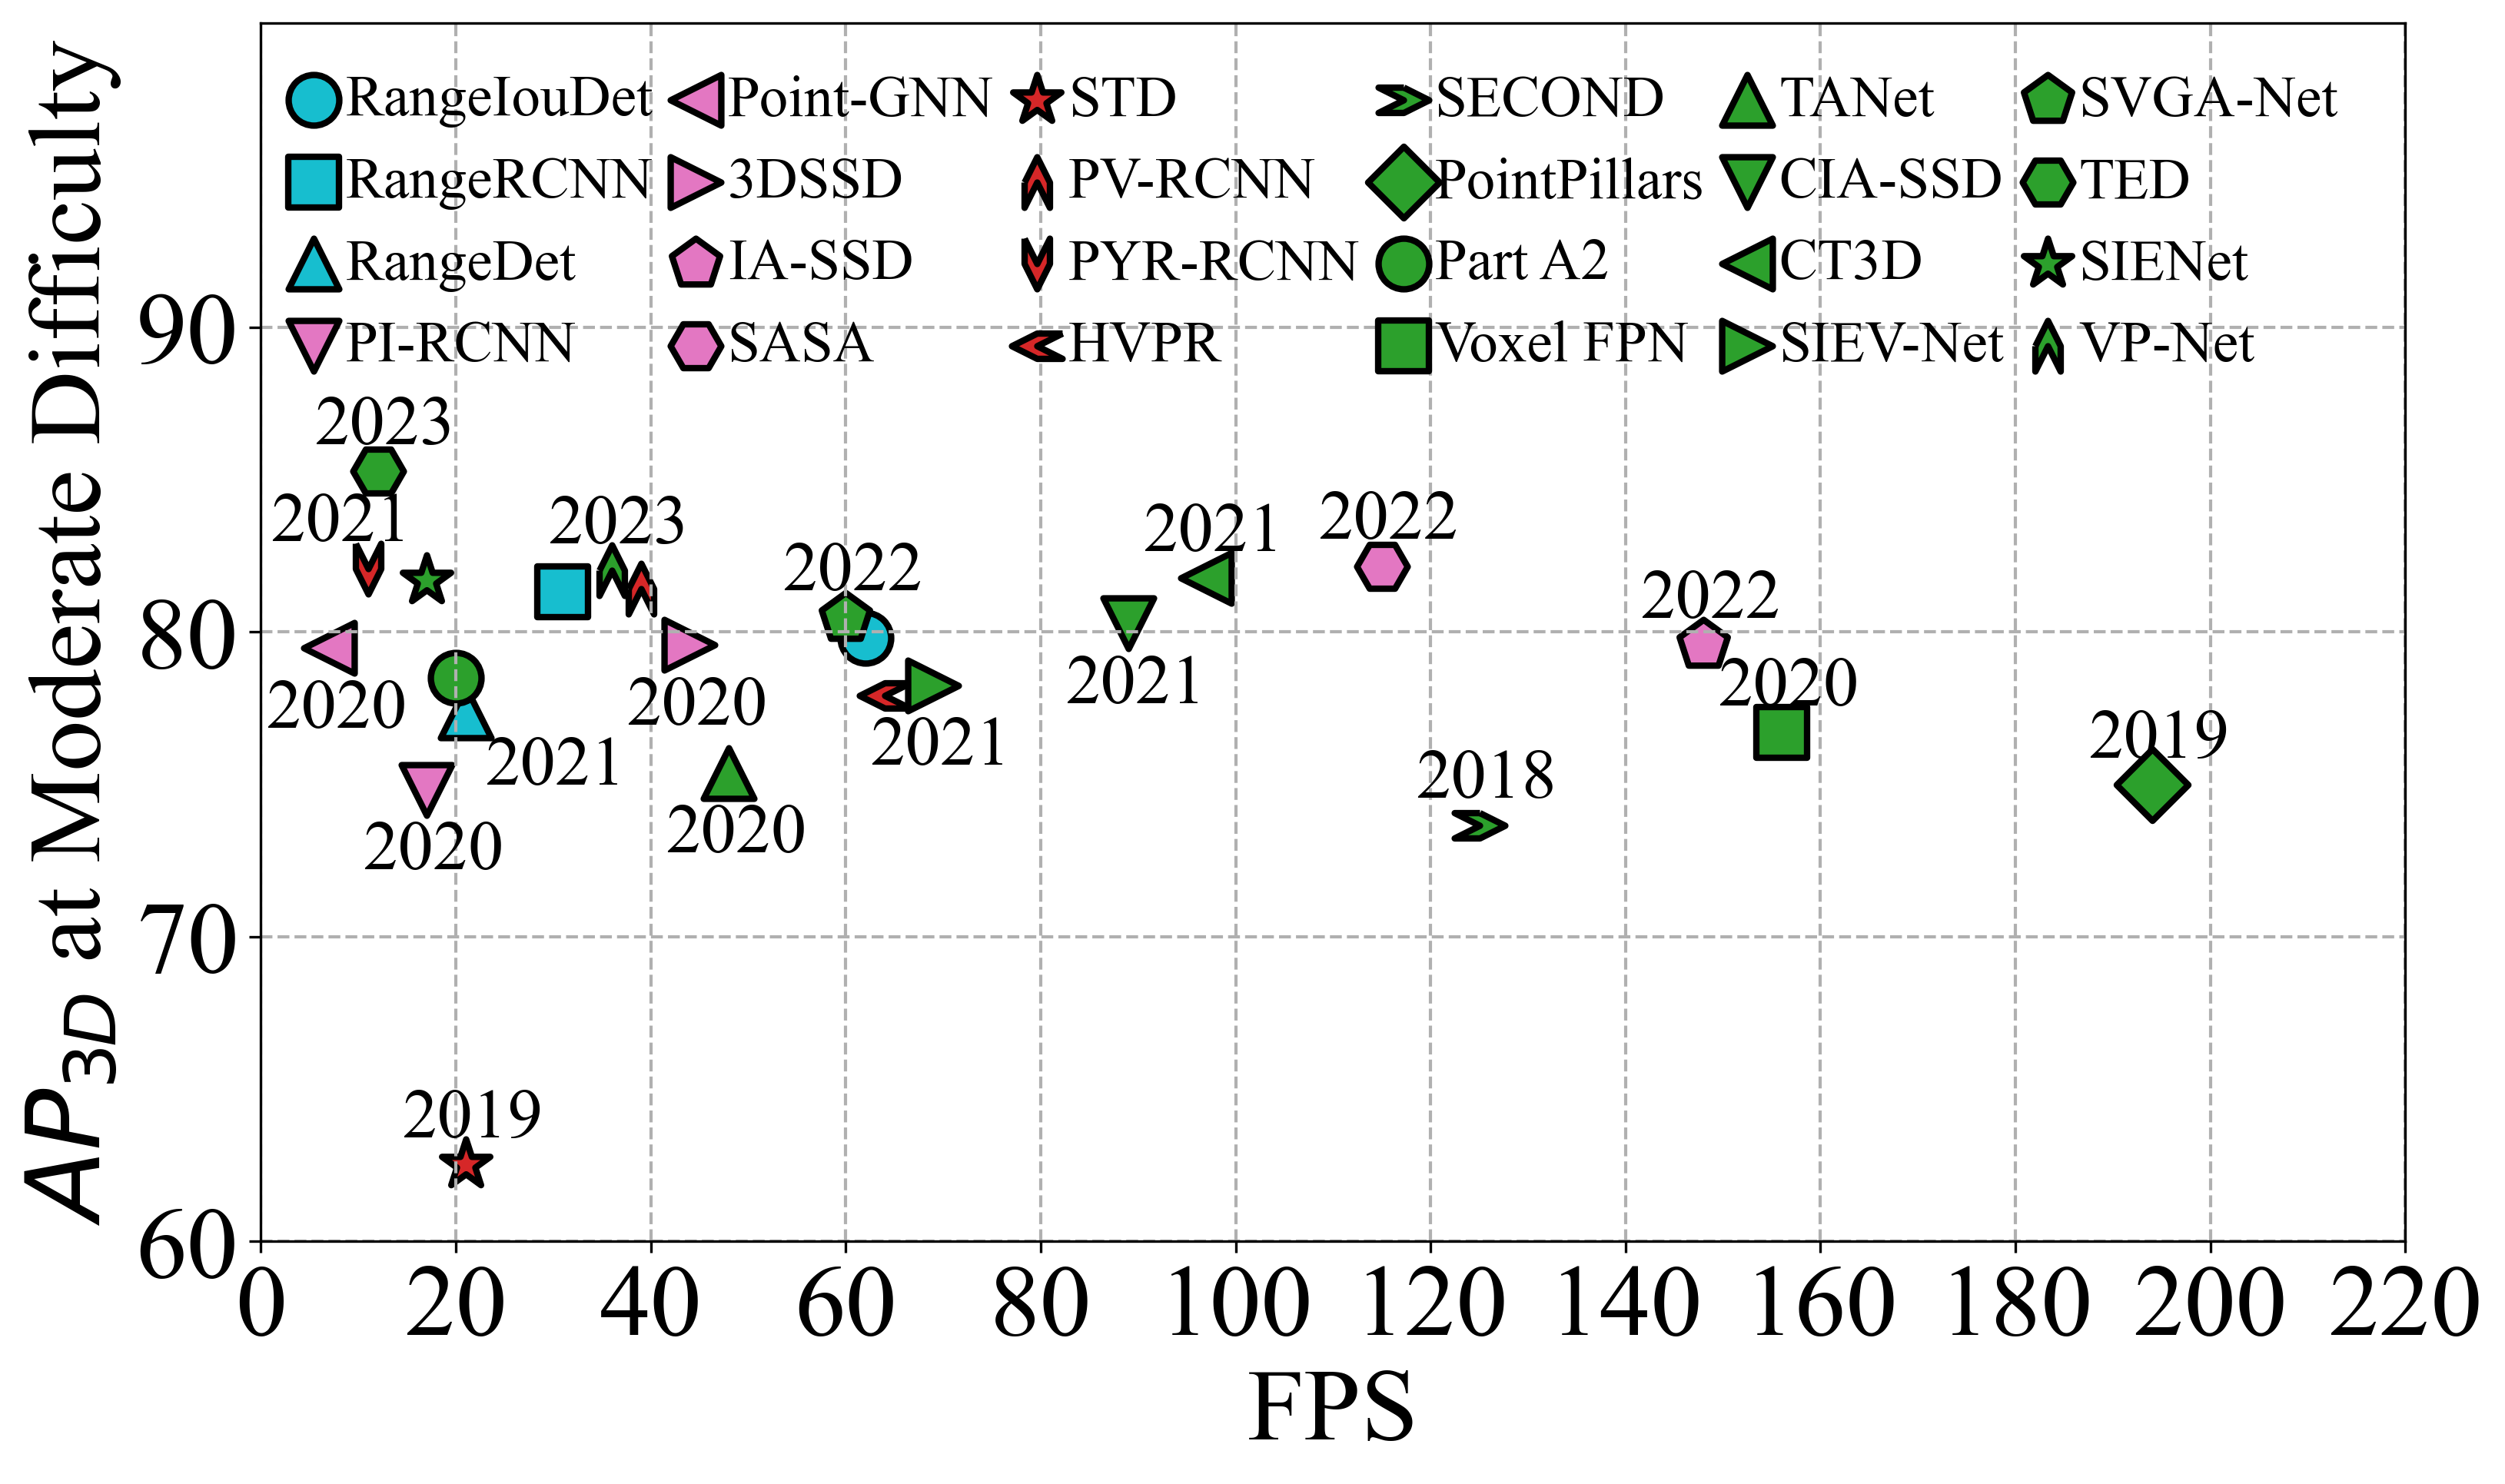

In [4]:
DATA3=[
    ############PROJECT BASED
#     ['PIXOR',1000/93 ,81.70,77.05,72.95,'2018','titanxp','pro'],
#     ['PIXOR++',1000/35 ,89.38,83.80,77.97,'2018','no','pro'],#fps来自hdnet 
#     ['HDNET',1000/50 ,89.14,86.57,78.32,'2018','no','pro'],
#     ['RCD', 1000 / 20, 70.54, 60.56, 55.58, '2020', 'no', 'pro'], # 0.02 s 榜单上的FPS  70.54 60.56 55.58
    ['RangeIouDet', 45, 88.60, 79.80, 76.76, '2021', 'v100', 'pro'], # 45FPS V100 88.60 79.80 76.76
    ['RangeRCNN', 22, 88.47, 81.33, 77.09, '2020', 'v100', 'pro'], # 15FPS V100 88.47 81.33 77.09
    ['RangeDet', 12, 85.41, 77.36, 72.60, '2021', '2080ti', 'pro'], #  12FPS 2080ti 85.41 % 77.36 %    72.60 %
    ############POINT BASED
#     ['PointRCNN',1000/100,85.94,75.76,68.32,'2019','no','p'],#fps来自榜单
    ['PI-RCNN',1000/90,84.37,74.82,70.03,'2020','titan','p'],
#     ['3D IoU-Net',1000/100,87.96,79.03,72.87,'2020','1080ti','p'],#fps来自榜单
    ['Point-GNN',1000/643,88.33,79.47,72.29,'2020','1070','p'],
    ['3DSSD',1000/38,88.36,79.57,74.55,'2020','titanv','p'],
    
    ['IA-SSD',83,88.36,79.57,74.55,'2022','2080ti','p'],
    ['SASA',83,88.76,82.16,77.16,'2022','v100','p'],
    # SPS-NET
    ############PV BASED
    ['STD',1000/80,78.89,62.53,57.85,'2019','titanv','pv'],
    ['PV-RCNN',12.5,90.25,81.43,76.82,'2020','1080ti','pv'],#fps来自IA-SSD,Pyramid-RCNN给9.25
    # VIC-NET
#     ['LiDar-RCNN',200,85.97,74.21,69.18,'2021','1080ti','pv'],#这条换出来变成1400了，200是原文给的
    ['PYR-RCNN',7.86,88.39,82.08,77.49,'2021','v100','pv'],
    
    ['HVPR',36.1,86.38,77.92,73.04,'2021','2080ti','pv'],
#     ['PV-RCNN++',10,88.36,79.57,74.55,'2023','titan','pv'],#无kitti结果
    ############V BASED
    ['SECOND',1000/25,83.13,73.66,66.20,'2018','1080ti','v'],
    ['PointPillars',62,79.05,74.99,68.30,'2019','1080ti','v'],
#     ['3D IoU Loss',1000/80,84.43,76.28,68.22,'2019','no','v'],#fps来自榜单
    ['Part A2',1000/70,87.81,78.49,73.51,'2020','v100','v'],
#     ['CenterNet3D',25,86.20,77.90,73.03,'2020','no','v'],
#     ['Associate 3Ddet',1000/60,85.99,77.40,70.53,'2020','1080ti','v'],
    
    ['Voxel FPN',50,85.64,76.70,69.44,'2020','1080ti','v'],
    ['TANet',1000/34.75, 83.81,75.38,67.66 ,'2020','titanv','v'],
    ['CIA-SSD',32,89.59,80.28,72.87 ,'2021','titanxp','v'],
    ['CT3D',70,87.83,81.77 ,77.16 ,'2021','v100','v'],#fps来自榜单
#     ['Voxel RCNN',25,90.90,81.62,77.06,'2021','2080ti','v'],
#     ['VoTr-TSD',14.65,89.90,82.09,79.14,'2021','v100','v'],
    ['SIEV-Net',22,88.91,78.25,76.39,'2021','1080ti','v'],
    ['SVGA-Net',1000/62,87.33 ,80.47 ,75.91 ,'2022','1080','v'],
#     ['CasA',1000/86,91.58 ,83.06 ,80.08 ,'2022','3090','v'],
    #voset
#     ['PDV',1000/135,90.43 ,81.86 ,77.36 ,'2022','titanxp','v'],
    ['TED',11,91.61 ,85.28 ,80.68 ,'2023','3090','v'],
    ['SIENet',6.2,88.22 ,81.71 ,77.22 ,'2023','titanxp','v'],
    ['VP-Net',20,90.46 ,82.03 ,79.65 ,'2023','2080ti','v'],
#     ['PG RCNN',60.1,89.38 ,77.33 ,75.91 ,'2023','3090','v'],
]

def draw3(Data):
    Data=fps_huansuan(Data,1,6,'a100')
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]
    aps_moderate = [item[3] for item in Data]
    researcher_types = [item[7] for item in Data]
    years = [item[5] for item in Data]

    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    for i, researcher_type in enumerate(researcher_types):
        colors = [f'C{9}',f'C{6}',f'C{3}',f'C{12}']
        if researcher_type=='pro':
            c = colors[0] 
        elif researcher_type=='p':
            c = colors[1]
        elif researcher_type=='pv':
            c = colors[2]
        else:
            c = colors[3]
        markers = get_markers()
        size = 250
        
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%len(markers)], label=model_names[i], 
                   color=c, s=size,edgecolor='black',linewidth=2)

        offset = 1
        text_size=22
        if i==3 or i==4 or i==5 or i==16 or i==17 or i==19:#正下方
            ax.text(delays[i]-6.5*offset, aps_moderate[i] - 2.6*offset, years[i], fontsize=text_size, color='black')
        elif i==0 or i==1 or i==2 or i==9 or i==10 or i==11 or i==14 or i==22:
            # 因为太挤了，所以这些点的年份空下不写，循环之后对这些进行处理
            print(model_names[i],years[i])
            continue
        else:#正上方
            ax.text(delays[i]-6.5*offset, aps_moderate[i] + 0.9*offset, years[i], fontsize=text_size, color='black')
    # 在图中画两个公用的年份，然后在其他作图软件内使用箭头连接更方便
    ax.text(23, 75, '2021', fontsize=22, color='black')
    ax.text(1, 83, '2021', fontsize=22, color='black')        
    
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel(r'$AP_{3D}$'+' at Moderate Difficulty',fontsize=32)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc="upper center", ncol=6,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5,columnspacing=1)
    ax.set_xticks(np.arange(0, 221, 20))
    ax.set_xlim(0, 220)
    # 这里写99.999是为了不出现100，100会让ylabel的位置向左边偏移，最终导致上下图的ylabel对不齐
    ## 手动设置让ylabel向右边靠的话，那个参数的值的寻找还是要费功夫的
    ### 因此使得y轴上不出现三位数，并同步所有子图的画布大小和dpi，让系统自动对齐这些文字是最方便且效果最好的
    #### 所有需要对齐和大小统一的地方基本都遵循上述原理：统一画布和统一设置
    ax.set_ylim(60, 99.99999)
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"

    plt.savefig('./pro+p+pv+v_kitti_ap+fps.png',bbox_inches='tight')
    plt.show()

draw3(DATA3)

Centerpoint 2020
Focals Conv-L 2022
UVTR-L 2020
PillarNet 2022
VISTA 2022
CVCNet 2020
CBGS 2019
VoxelNeXt 2023
Transfusion-L 2023
FocalFormer3D-L 2023


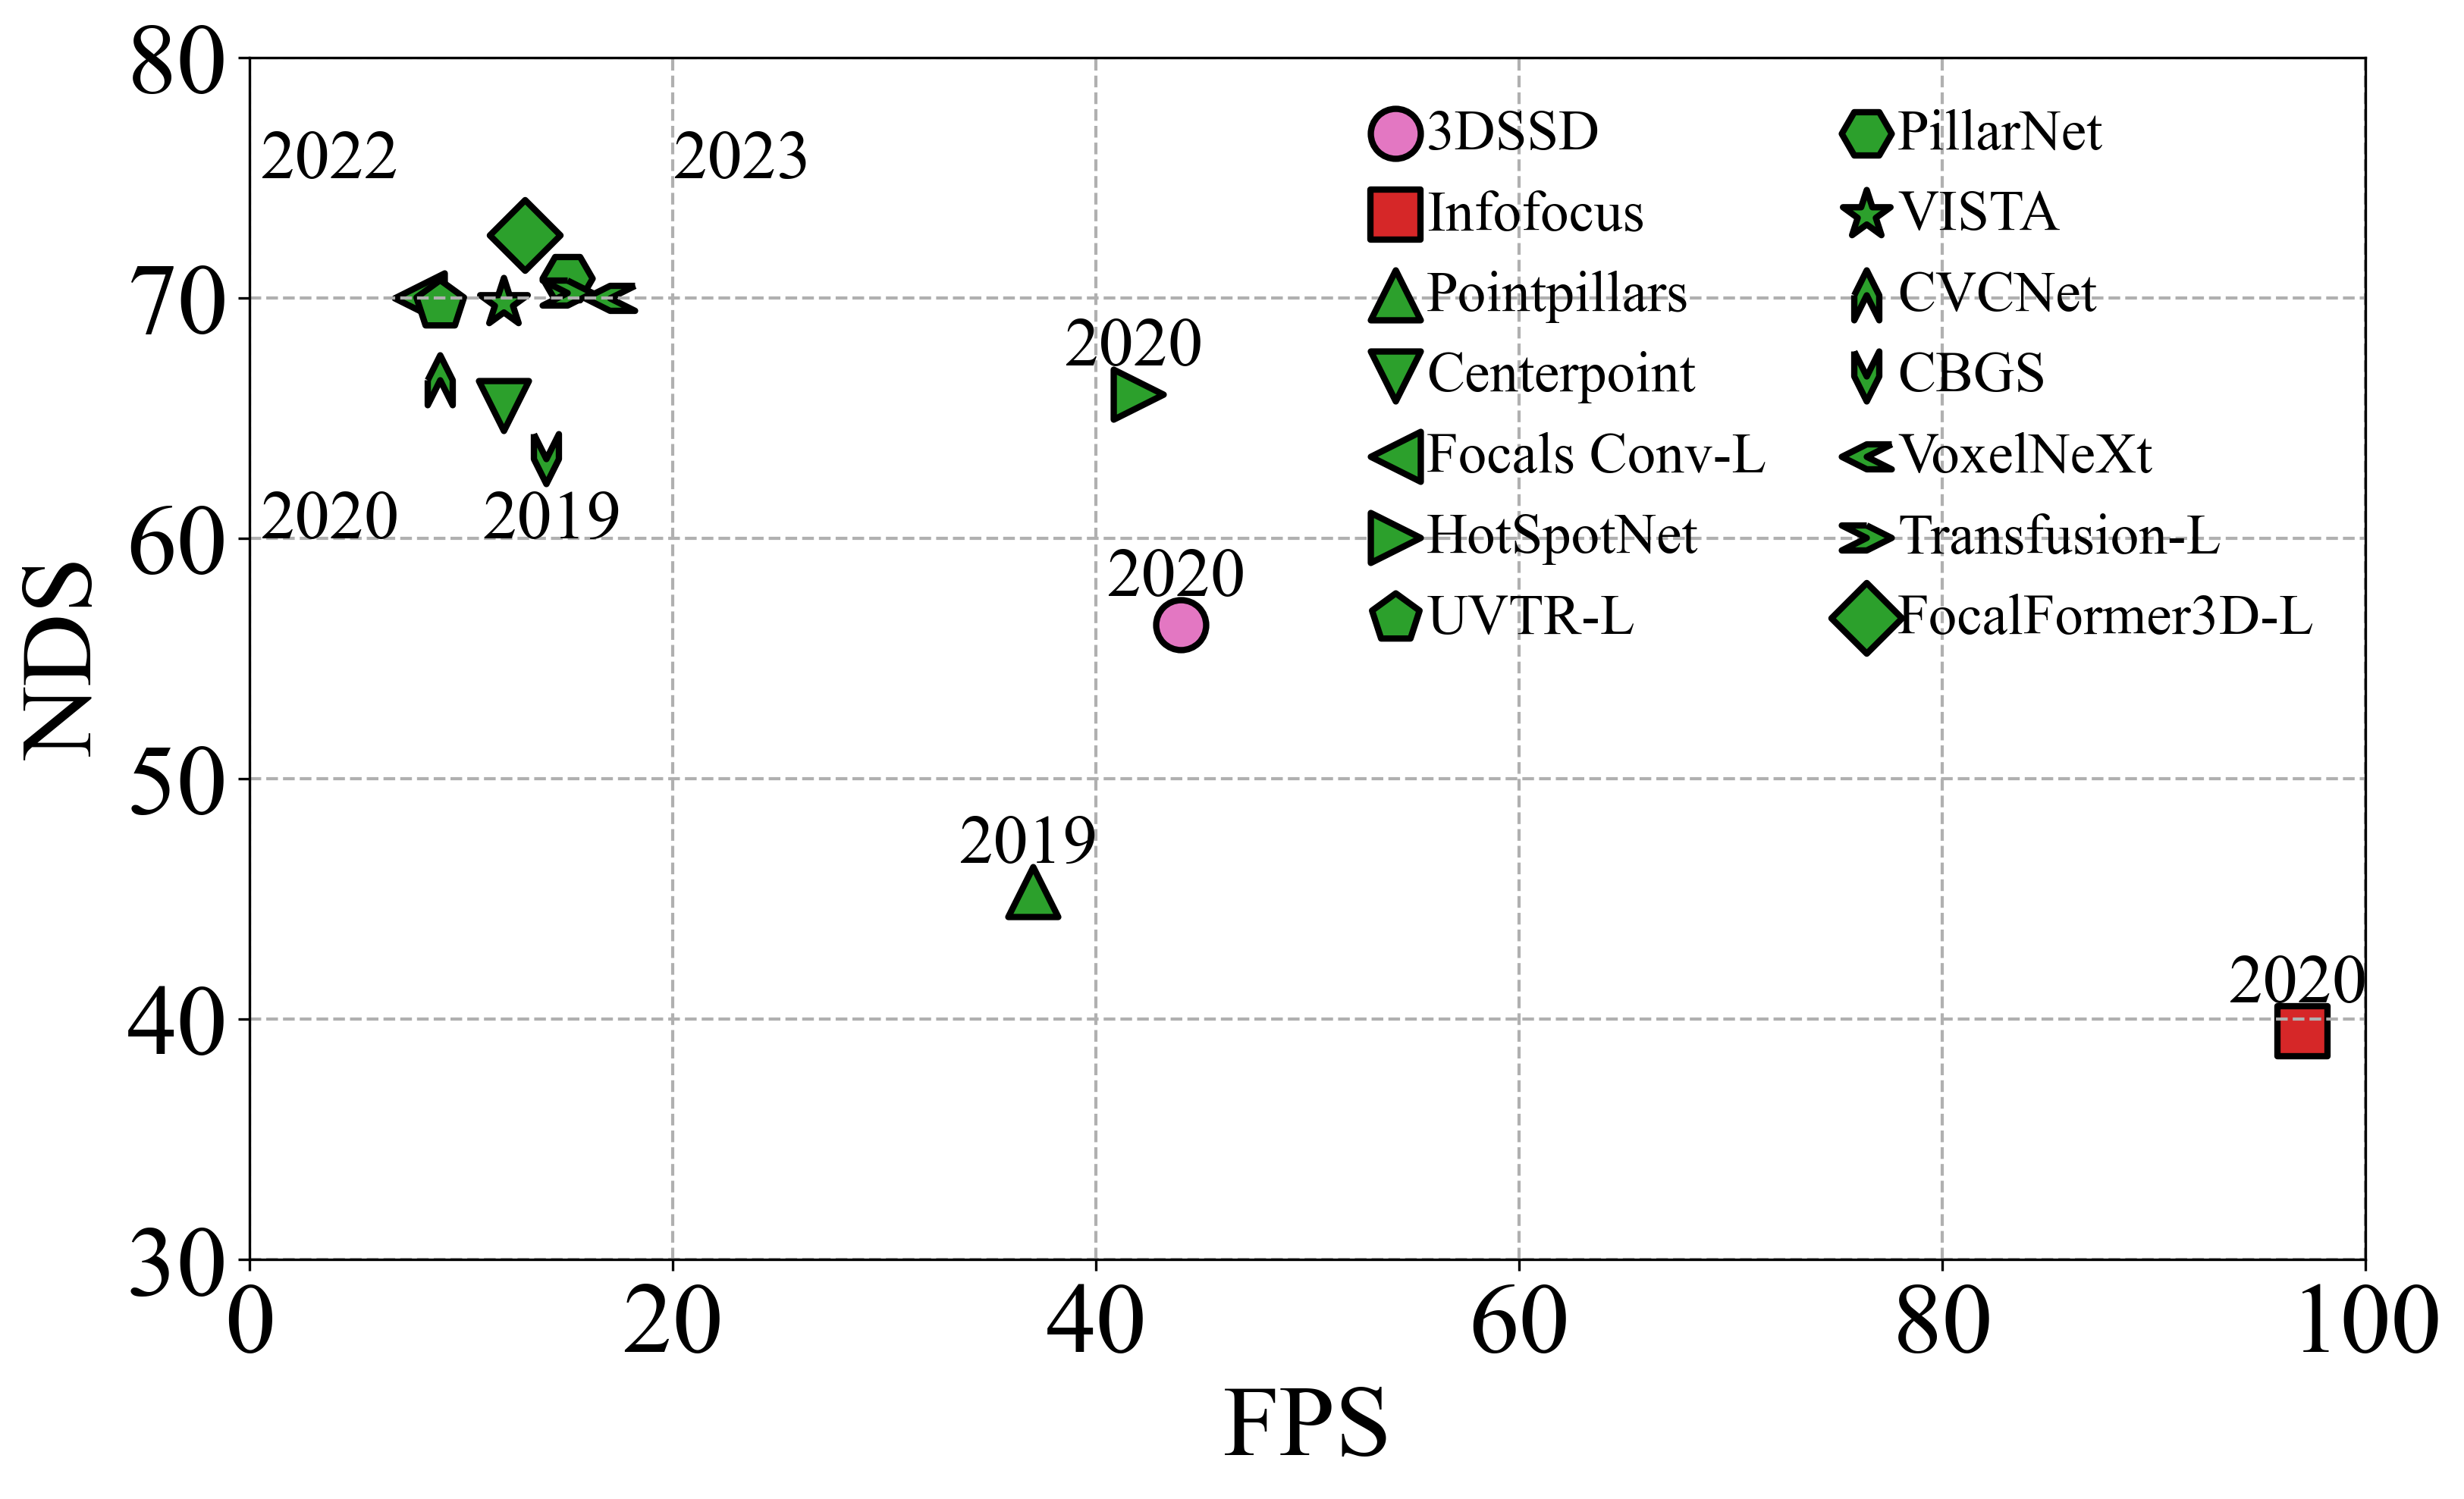

In [5]:
DATA4=[
    #point
    ['3DSSD', 1000 / 38, 56.4, 42.6,'2020', 'titanv', 'p'],# 56.4 42.6
    #voxel
    ['Infofocus', 31, 39.5, 39.5,'2020', '1080ti', 'pv'], # 1080ti
    #point-voxel
    ['Pointpillars', 1000/31, 45.3, 30.5,'2019', '3090', 'v'], # voxelnext
    ['Centerpoint', 1000/96, 65.5, 58.0,'2020', '3090', 'v'],# voxelnext
    ['Focals Conv-L', 1000/138, 70.0, 63.8,'2022', '3090', 'v'],# voxelnext
    ['HotSpotNet',25, 66.0, 59.3,'2020', 'titanv', 'v'],
    ['UVTR-L',1000/132, 69.7, 63.9,'2020', '3090', 'v'],# voxelnext
    ['PillarNet',1000/78, 70.8, 65.0,'2022', '3090', 'v'],# voxelnext
    ['VISTA',1000/94, 69.8, 63.0,'2022', '3090', 'v'],# voxelnext
    ['CVCNet',1000/122, 66.6, 58.2 ,'2020', '3090', 'v'],# voxelnext
    ['CBGS', 1000/80, 63.3, 52.8,'2019','3090','v' ],# voxelnext
    ['VoxelNeXt', 1000/66, 70.0, 64.5, '2023','3090','v'],# voxelnext
    ['Transfusion-L', 1000/93, 70.2, 65.5, '2023','v100','v'],
    ['FocalFormer3D-L', 1000/109, 72.6, 68.7, '2023','v100','v'],
]

def draw4(Data):
    Data=fps_huansuan(Data,1,5,'a100')
    
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]
    aps_moderate = [item[2] for item in Data]
    researcher_types = [item[6] for item in Data]
    years = [item[4] for item in Data]

    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    for i, researcher_type in enumerate(researcher_types):
        colors = [f'C{9}',f'C{6}',f'C{3}',f'C{12}']
        if researcher_type=='pro':
            c = colors[0] 
        elif researcher_type=='p':
            c = colors[1]
        elif researcher_type=='pv':
            c = colors[2]
        else:
            c = colors[3]

        markers = get_markers()
        
        size = 250
        
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%len(markers)], label=model_names[i], 
                   color=c, s=size,edgecolor='black',linewidth=2)

        offset = 1
        text_size=22
        if i==0 or i==1 or i==2 or i==5:#正下方
            ax.text(delays[i]-3.5*offset, aps_moderate[i] + 1.2*offset, years[i], fontsize=text_size, color='black')
        else:
            print(model_names[i],years[i])
            continue
            
    ax.text(11, 60, '2019', fontsize=22, color='black')
    ax.text(0.5, 60, '2020', fontsize=22, color='black')
    ax.text(0.5, 75, '2022', fontsize=22, color='black')
    ax.text(20, 75, '2023', fontsize=22, color='black')
    
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel('NDS',fontsize=32)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc='upper right', ncol=2,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5)  # 2 columns in legend
    ax.set_xticks(np.arange(0, 201, 20))
    ax.set_xlim(0, 100)
    ax.set_ylim(30, 80)
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"

    plt.savefig('./pro+p+pv+v_nus_nds+fps.png',bbox_inches='tight')
    plt.show()

draw4(DATA4)

Focals Conv 2022
HMFI 2022
R-FusionNet 2022


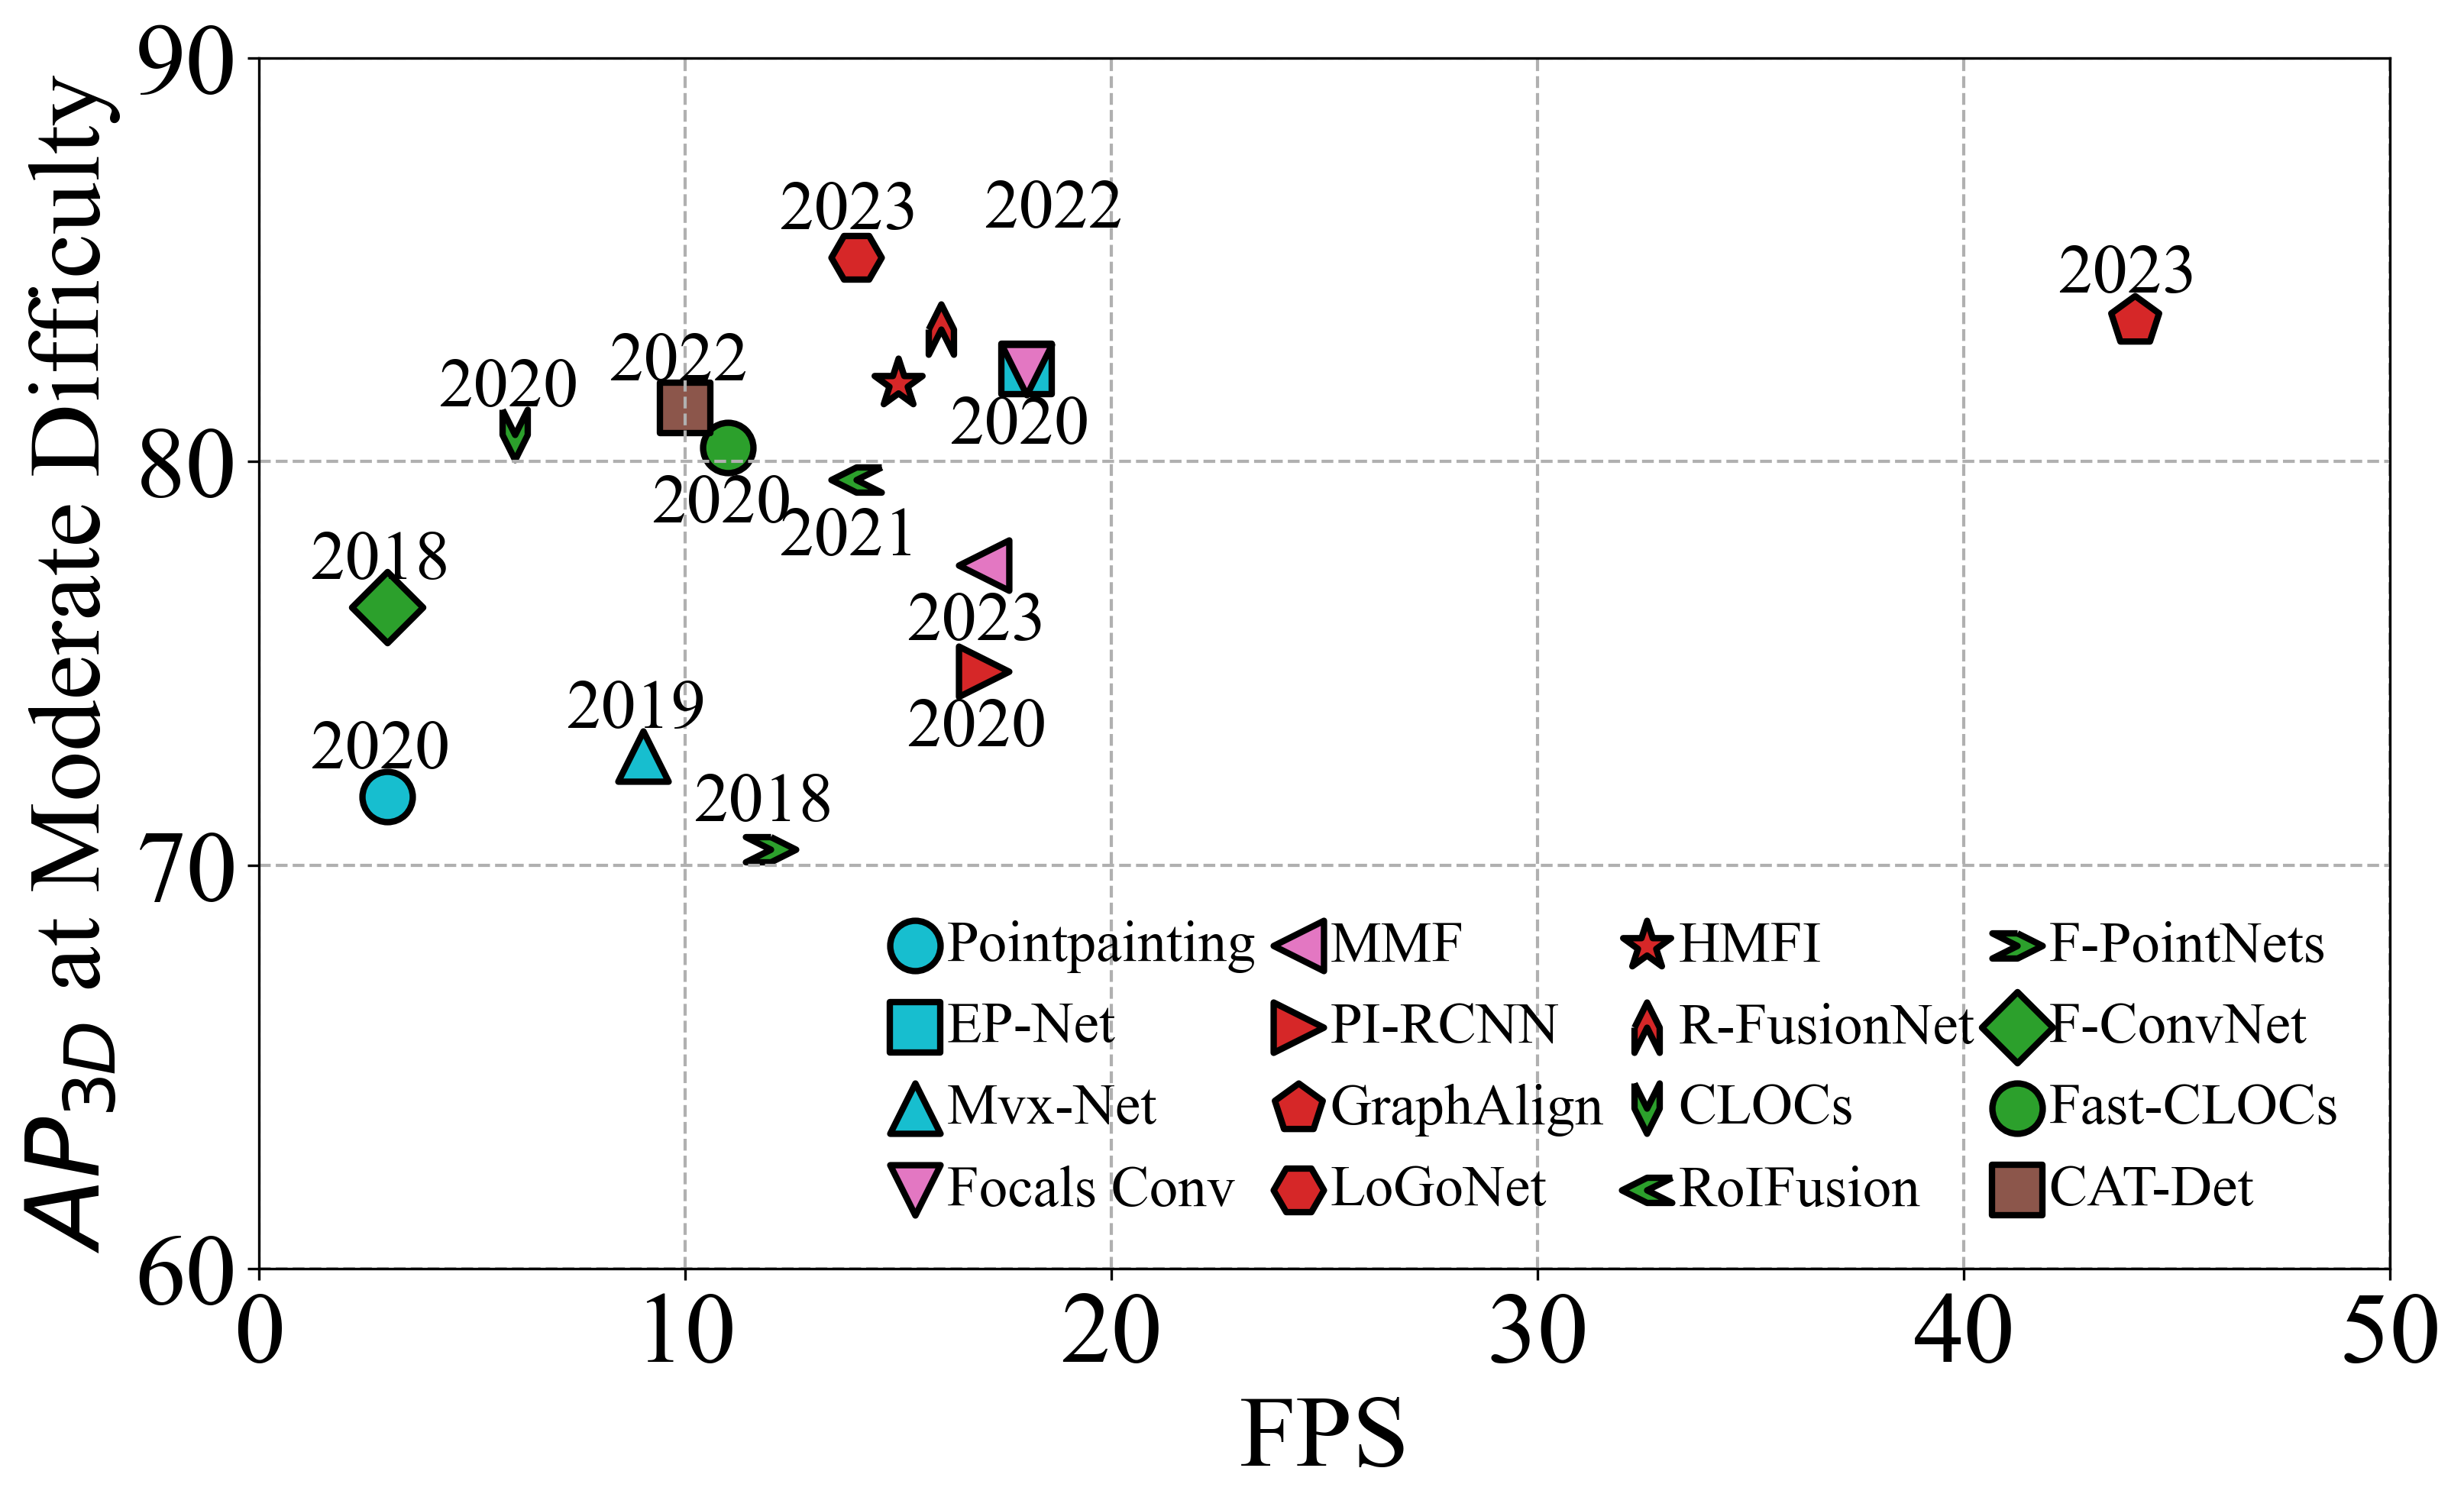

In [6]:
#zhiyou kitti: roarnet Complexer-YOLO LaserNet epnet epnet++ LaserNet++(mvp) mvx-net
DATA5=[
    ['Pointpainting',1000/400,82.11,71.70,67.08 ,'2020','no','1'],
#     ['Complexer-YOLO',1000/60,55.93,47.34,42.60 ,'2019','no','1'],
    ['EP-Net',1000/100,91.70,82.29,79.80 ,'2020','2080ti','1'],
#     ['EP-Net++',1000/100,91.37,81.96,76.71 ,'2022','no','1'],
#     ['FusionPainting',-1,66.3,70.4,'2021','no','1'],#nus
#     ['CenterFusion',-1,33.2,45.3,'2021','p5000','1'],#nus,'I+R'
    ['Mvx-Net',1000/160,83.2,72.7,65.2 ,'2019','no','1'],
    
    ['Focals Conv',1000/100,90.55,82.28,77.59,'2022','2080ti','2'],
#     ['PointFusion',-1,77.92,63.00,53.27,'2018','no','2'],
#     ['VFF(PV-RCNN)',-1,92.47,85.65,83.38,'2022','no','2'],
#     ['SupFusion',-1,92.42,85.47,82.83,'2023','a100','2'],
    ['MMF',1000/80,88.40,77.43,70.22,'2023','no','2'],

    ['PI-RCNN',1000/90,84.3,74.8,70.03,'2020','titan','3'],
#     ['3D-CVF',1000/75,89.20,80.05,73.11,'2020','1080ti','3'],
    ['GraphAlign',1000/26,90.96,83.49, 80.14,'2023','a6000','3'],
    ['LoGoNet',1000/100,91.80,85.06,80.74,'2023','no','3'],
    ['HMFI',1000/90,88.90,81.93,77.30,'2022','no','3'],
    ['R-FusionNet',1000/110,92.69,83.27,80.95,'2022','2080ti','3'],
#     ['3D Dual-Fusion',1000/100,91.01,82.40,79.39,'2022','no','3'],
    
    ['CLOCs',1000/250,88.94,80.67,77.15,'2020','3080','4'],
#     ['AVOD',1000/80,60.11,44.90,38.80,'2018','titanxp','4'],
#     ['MV3D',1000/36,74.97,63.63 ,54.00,'2017','titanx','4'],
    ['RoIFusion',1000/220,88.32,79.54 ,74.47,'2021','1080ti','4'],
    ['F-PointNets',1000/120,81.20,70.39,62.19,'2018','no','4'],
    ['F-ConvNet',1000/470,87.36,76.39,66.69,'2018','no','4'],
#     ['F-PointPillars',1000/70,51.22,42.89,39.28,'2021','1080','4'],
    ['Fast-CLOCs',8,89.11,80.34,76.98,'2020','3080','4'],

    ['CAT-Det',1000/300,89.87,81.32,76.68,'2022','1080ti','5'],
]

def draw5(Data):
    Data=fps_huansuan(Data,1,6,'a100')
    
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]
    aps_moderate = [item[3] for item in Data]
    researcher_types = [item[7] for item in Data]
    years = [item[5] for item in Data]

    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    for i, researcher_type in enumerate(researcher_types):
        colors = [f'C{9}',f'C{6}',f'C{3}',f'C{12}',f'C{15}',f'C{18}',]
        if researcher_type=='1':
            c = colors[0] 
        elif researcher_type=='2':
            c = colors[1]
        elif researcher_type=='3':
            c = colors[2]
        elif researcher_type=='4':
            c = colors[3]
        elif researcher_type=='5':
            c = colors[4]
        else:
            c = colors[5]

        markers = get_markers()
        
        size = 250  
        
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%len(markers)], label=model_names[i], 
                   color=c, s=size,edgecolor='black',linewidth=2)
        
        offset = 1
        text_size=22
        if i==1 or i==4 or i==5 or i==11 or i==14:#正下方
            ax.text(delays[i]-1.8*offset, aps_moderate[i] - 1.85*offset, years[i], fontsize=text_size, color='black')
        elif i==3 or i==8 or i==9:
            print(model_names[i],years[i])
            continue
        else:#正上方
            ax.text(delays[i]-1.8*offset, aps_moderate[i] + 0.7*offset, years[i], fontsize=text_size, color='black')
    
    ax.text(17, 85.8, '2022', fontsize=22, color='black')
    
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel(r'$AP_{3D}$'+' at Moderate Difficulty',fontsize=32)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc='lower right', ncol=4,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5,columnspacing=1)  # 2 columns in legend
    ax.set_xticks(np.arange(0, 201, 10))
    ax.set_xlim(0, 50)
    ax.set_ylim(60, 90)
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"
    
    plt.savefig('./multimodal_kitti_ap+fps.png',bbox_inches='tight')
    plt.show()

draw5(DATA5)

AutoAlignV2 2022
Transfusion 2022
SparseFusion 2023


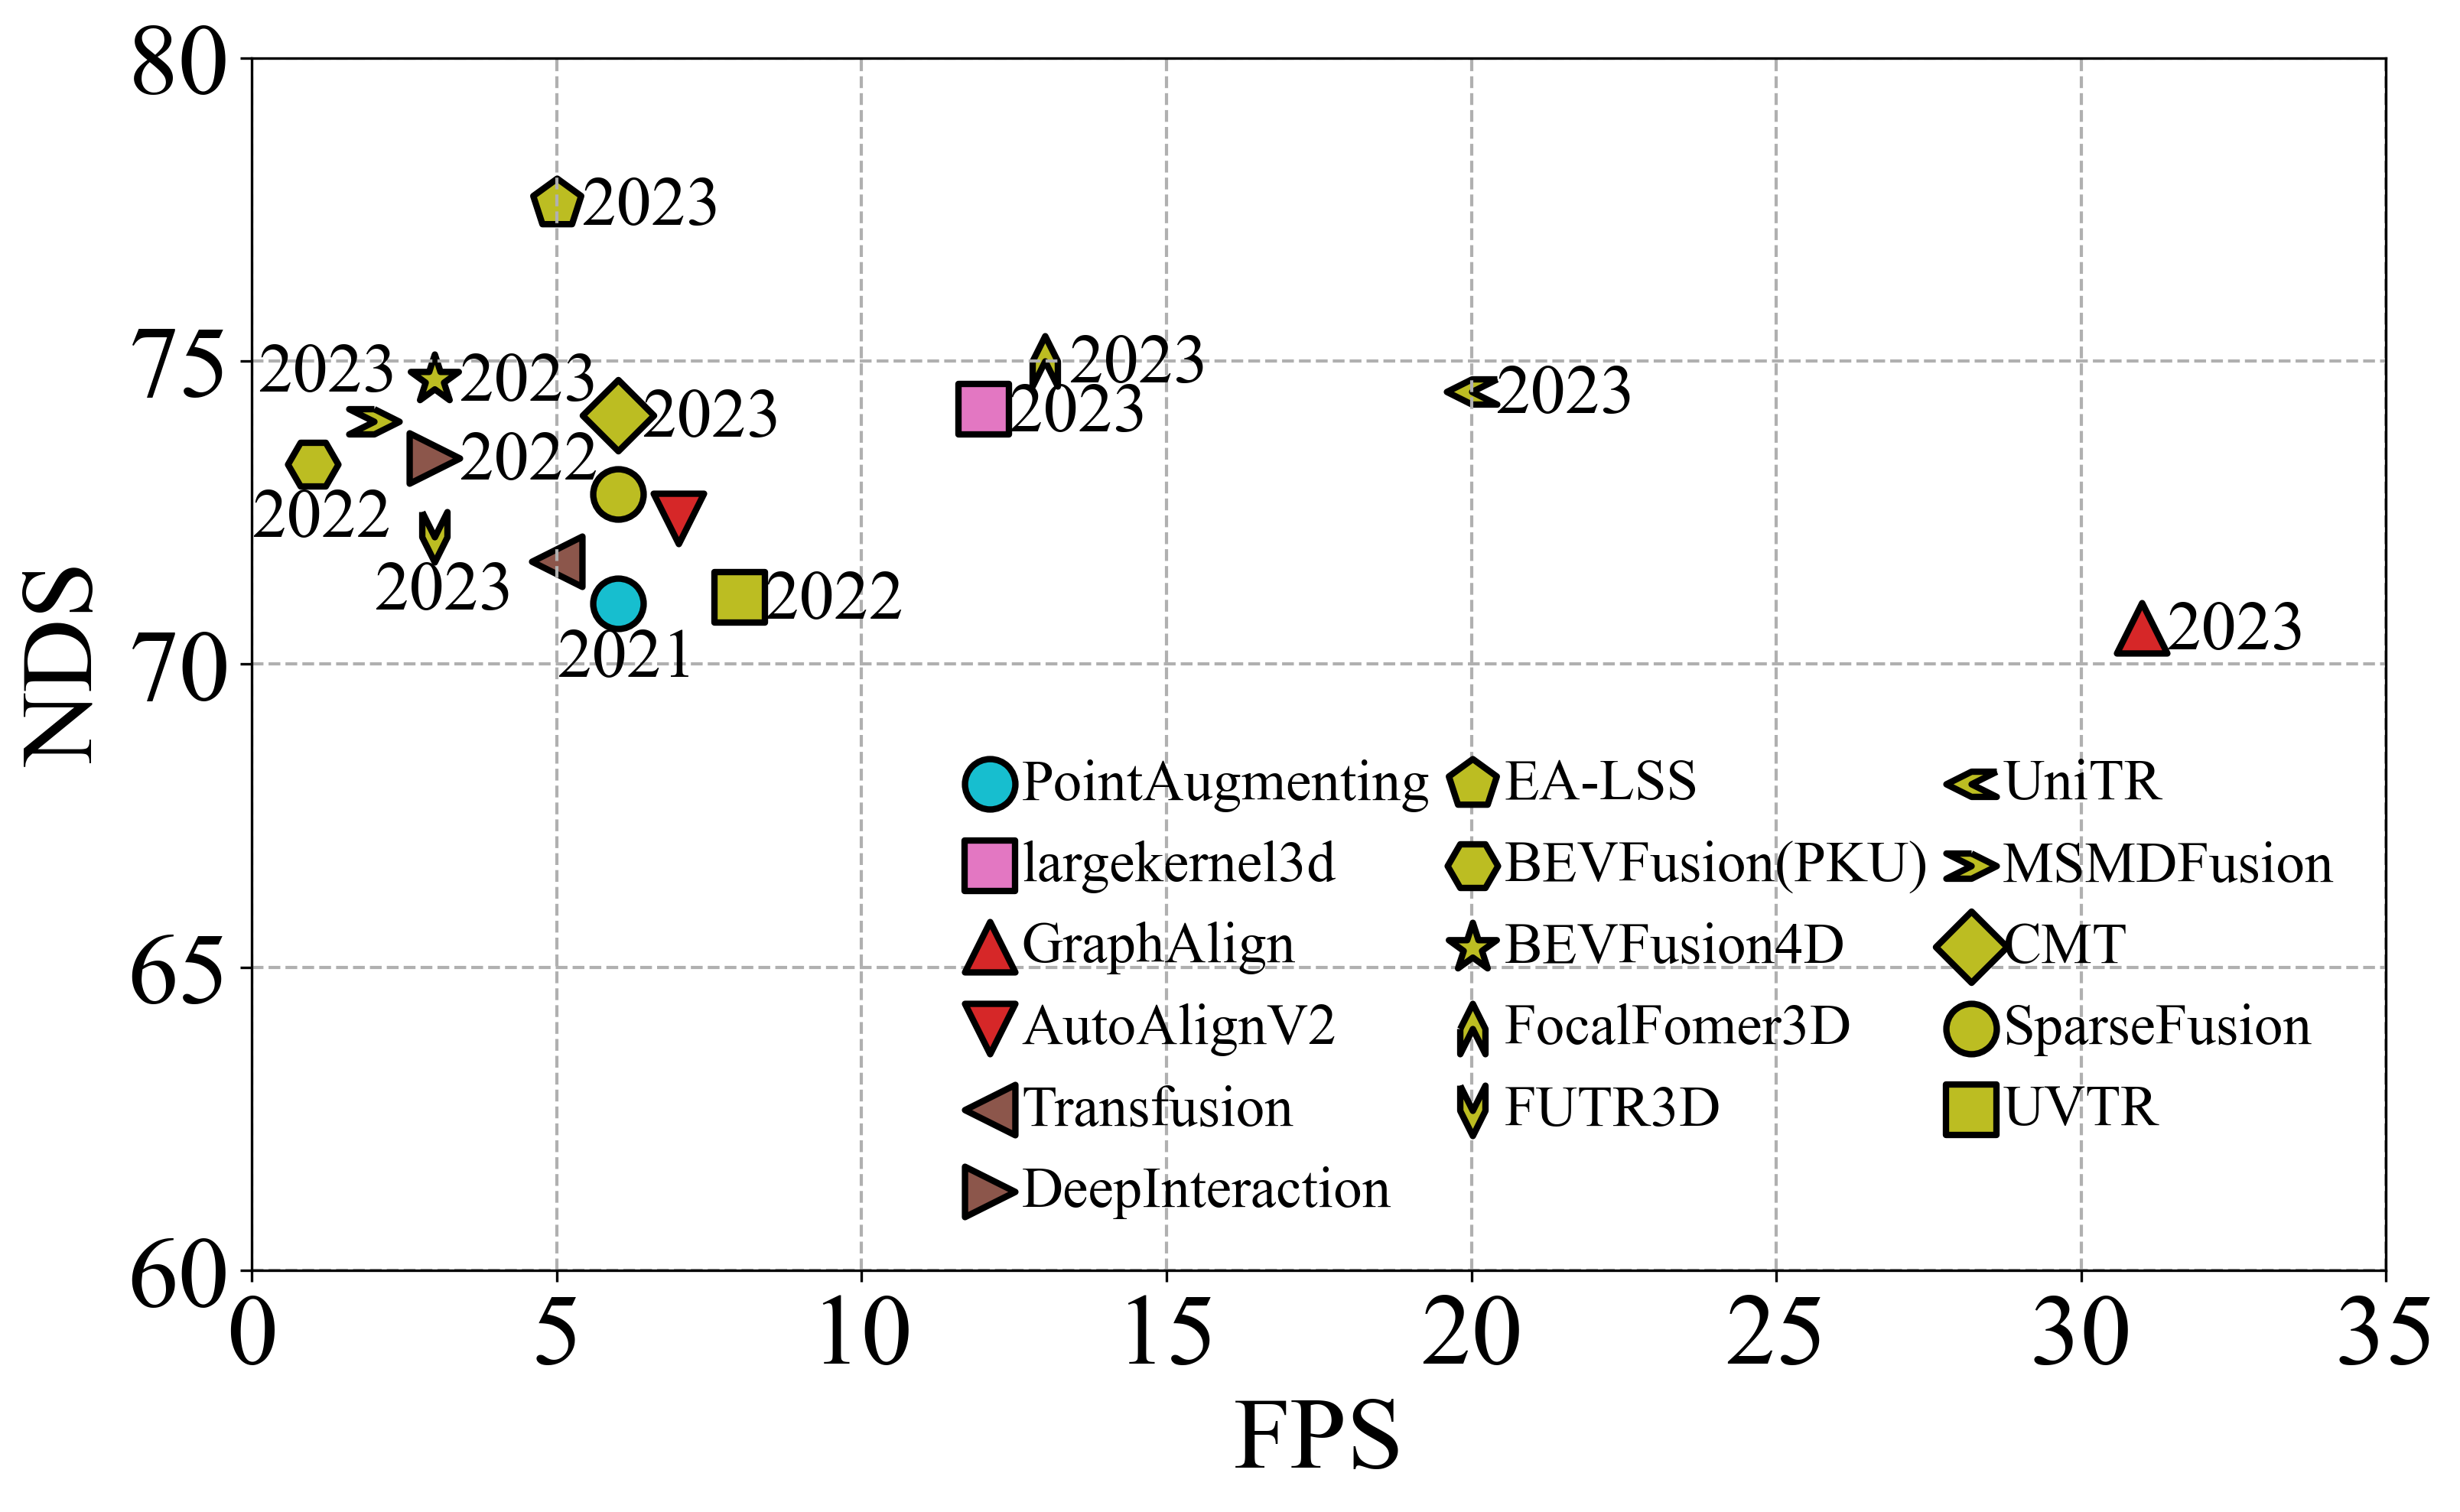

In [7]:
DATA6=[
#     ['Pointpainting(PointPillars+)',-1,46.4,58.1 ,'2020','no','1'],#nus
    ['PointAugmenting',1000/542,66.8,71.0 ,'2021','1080ti','1'],#nus
#     ['FusionPainting',-1,66.3,70.4,'2021','no','1'],#nus
#     ['CenterFusion',-1,33.2,45.3,'2021','p5000','1'],#nus,'I+R'
    
    ['largekernel3d',1000/145,71.2,74.2,'2023','2080ti','2'],#nus
        
    ['GraphAlign',1000/37,66.5,70.6,'2023','a6000','3'],#nus
    ['AutoAlignV2',1000/208,68.4,72.4 ,'2022','v100','3'],#nus,i+v
    
    ['Transfusion',1000/265,68.9,71.7,'2022','v100','5'],
    #deepfusion waymo
    ['DeepInteraction',2.5,70.8,73.4,'2022','v100','5'],
#     ['AutoAlign',-1,66.6,71.1,'2022','no','5'],
    #mixedfusion nus的夜晚和雨部分，没法用
    ['EA-LSS',1000/190,76.5,77.6,'2023','a100','6'],
    ['BEVFusion(PKU)',1000/1230,71.3,73.3,'2022','a100','6'],
    ['BEVFusion4D',2,73.3,74.7,'2023','v100','6'],
    ['FocalFomer3D',1000/109,72.9,75.0,'2023','v100','6'],
    ['FUTR3D',1000/302,69.4,72.1,'2023','a100','6'],
    ['UniTR',1000/50.2,70.9,74.5,'2023','a100','6'],
    #uni3d 无延迟
    ['MSMDFusion',2.1,71.5,74.0,'2023','3090','6'],
    ['CMT',6.4,72.0,74.1,'2023','a100','6'],
    ['SparseFusion',5.6,70.4,72.8,'2023','a6000','6'],
    ['UVTR',5.6,67.1,71.1,'2022','v100','6'],
    
]

def draw6(Data):
    Data=fps_huansuan(Data,1,5,'a100')
    
    model_names = [item[0] for item in Data]
    delays = [item[1] for item in Data]
    aps_moderate = [item[3] for item in Data]
    researcher_types = [item[6] for item in Data]
    years = [item[4] for item in Data]

    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    for i, researcher_type in enumerate(researcher_types):
        colors = [f'C{9}',f'C{6}',f'C{3}',f'C{12}',f'C{15}',f'C{18}',]
        if researcher_type=='1':
            c = colors[0] 
        elif researcher_type=='2':
            c = colors[1]
        elif researcher_type=='3':
            c = colors[2]
        elif researcher_type=='4':
            c = colors[3]
        elif researcher_type=='5':
            c = colors[4]
        else:
            c = colors[5]
        
        markers = get_markers()
        
        size = 250
        
        ax.scatter(delays[i], aps_moderate[i], marker=markers[i%len(markers)], label=model_names[i], 
                   color=c, s=size,edgecolor='black',linewidth=2)

        offset = 1
        text_size=22
        if i==0 or i==7 or i==10:#正下方
            ax.text(delays[i]-1*offset, aps_moderate[i] - 1.2*offset, years[i], fontsize=text_size, color='black')
        elif i==12:#左上侧
            ax.text(delays[i]-1.9*offset, aps_moderate[i]+ 0.5*offset, years[i], fontsize=text_size, color='black')
        elif i==3 or i==4 or i==14:
            print(model_names[i],years[i])
        else:#正右方
            ax.text(delays[i]+0.4*offset, aps_moderate[i] - 0.35*offset, years[i], fontsize=text_size, color='black')
    
    ax.set_xlabel('FPS',fontsize=32)
    ax.set_ylabel('NDS',fontsize=32)
    ax.tick_params(axis='x',labelsize=32)
    ax.tick_params(axis='y',labelsize=32)
    ax.legend(loc='lower right', ncol=3,fontsize=18,shadow=False, 
                   fancybox=False,frameon=False,handlelength=-0.5,columnspacing=1)  # 2 columns in legend
    ax.set_xticks(np.arange(0, 201, 5))
    ax.set_xlim(0, 35)
    ax.set_ylim(60, 80)
    ax.grid(True, linestyle='--', alpha=1, linewidth=1)
    plt.rcParams["font.family"] = "Times New Roman"

    plt.savefig('./multimodal_nus_nds+fps.png',bbox_inches='tight')
    plt.show()

draw6(DATA6)